# Logistic Regression: Predict Pass/Fail from Study Hours and Attendance

This notebook implements logistic regression to classify students as **pass** or **fail** based on two features: study hours and attendance. It follows the same simple structure used in the earlier notebooks and includes: Problem Statement, Understanding of Dataset, Theory, Mathematical Representation, Diagram, Pseudocode, Expected Output, and Obtained Output.

The implementation also includes data cleaning, EDA, feature scaling, feature engineering, and evaluation using accuracy-based classification metrics.

In [1]:
# Imports and Synthetic CSV Generation
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import joblib

DATA_PATH = "student_pass_fail.csv"
FEATURE_COLS = ["study_hours", "attendance"]
TARGET_COL = "result"

if not os.path.exists(DATA_PATH):
    np.random.seed(42)
    n = 180
    study_hours = np.round(np.random.uniform(0, 12, n), 2)
    attendance = np.round(np.random.uniform(40, 100, n), 2)

    score = 0.55 * study_hours + 0.045 * attendance + np.random.normal(0, 0.8, n)
    result = (score >= 5.0).astype(int)

    df_sample = pd.DataFrame({
        "study_hours": study_hours,
        "attendance": attendance,
        TARGET_COL: result
    })
    df_sample.to_csv(DATA_PATH, index=False)
    print(f"✓ Sample CSV created: {DATA_PATH} with {n} samples")
else:
    print(f"✓ Found existing {DATA_PATH}, will use it")

print(f"\nFirst 5 rows of {DATA_PATH}:")
print(pd.read_csv(DATA_PATH).head())

✓ Sample CSV created: student_pass_fail.csv with 180 samples

First 5 rows of student_pass_fail.csv:
   study_hours  attendance  result
0         4.49       60.46       1
1        11.41       46.81       1
2         8.78       95.48       1
3         7.18       92.64       1
4         1.87       55.48       0


## 1. Problem Statement

Create a logistic regression model to predict whether a student will **pass** or **fail** based on study hours and attendance.

## 2. Understanding of Dataset

Load the dataset and inspect its shape, data types, and summary statistics.

In [2]:
df = pd.read_csv(DATA_PATH)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print("\nFirst 10 rows:")
print(df.head(10))

print(f"\nDataset shape: {df.shape}")
print(f"Samples: {df.shape[0]}, Features: {df.shape[1]}")

print("\nColumn data types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe().T)

print("\nClass Distribution:")
print(df[TARGET_COL].value_counts())

DATASET OVERVIEW

First 10 rows:
   study_hours  attendance  result
0         4.49       60.46       1
1        11.41       46.81       1
2         8.78       95.48       1
3         7.18       92.64       1
4         1.87       55.48       0
5         1.87       79.60       1
6         0.70       89.03       0
7        10.39       73.31       1
8         7.21       71.78       1
9         8.50       54.51       1

Dataset shape: (180, 3)
Samples: 180, Features: 3

Column data types:
study_hours    float64
attendance     float64
result           int64
dtype: object

Statistical Summary:
             count       mean        std    min      25%    50%      75%  \
study_hours  180.0   5.665278   3.528754   0.07   2.6400   5.57   8.7525   
attendance   180.0  70.486000  17.371590  40.30  55.8025  72.74  83.7450   
result       180.0   0.677778   0.468631   0.00   0.0000   1.00   1.0000   

               max  
study_hours  11.84  
attendance   99.40  
result        1.00  

Class Distributi

## 3. Data Cleaning

Check for missing values, duplicates, and invalid values.

In [3]:
print("="*60)
print("DATA CLEANING")
print("="*60)

print("\n1. Missing Values Check:")
missing = df.isnull().sum()
print(f"Missing values per column:\n{missing}")
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    df = df.dropna()

print("\n2. Duplicate Rows Check:")
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"× Removed {dupes} duplicate(s)")
else:
    print("✓ No duplicates found")

print("\n3. Invalid Values Check:")
invalid_hours = (df["study_hours"] < 0).sum()
invalid_attendance = ((df["attendance"] < 0) | (df["attendance"] > 100)).sum()
invalid_result = (~df[TARGET_COL].isin([0, 1])).sum()
print(f"Invalid study hours: {invalid_hours}")
print(f"Invalid attendance: {invalid_attendance}")
print(f"Invalid result values: {invalid_result}")

df = df[(df["study_hours"] >= 0) & (df["attendance"] >= 0) & (df["attendance"] <= 100)]
df = df[df[TARGET_COL].isin([0, 1])].reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

DATA CLEANING

1. Missing Values Check:
Missing values per column:
study_hours    0
attendance     0
result         0
dtype: int64
✓ No missing values found

2. Duplicate Rows Check:
Duplicate rows: 0
✓ No duplicates found

3. Invalid Values Check:
Invalid study hours: 0
Invalid attendance: 0
Invalid result values: 0

Dataset shape after cleaning: (180, 3)


## 4. Exploratory Data Analysis (EDA)

Explore how study hours and attendance relate to pass/fail result.

EXPLORATORY DATA ANALYSIS


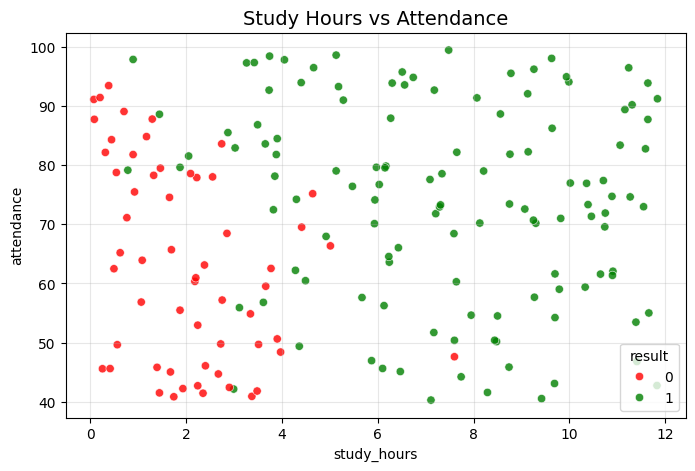

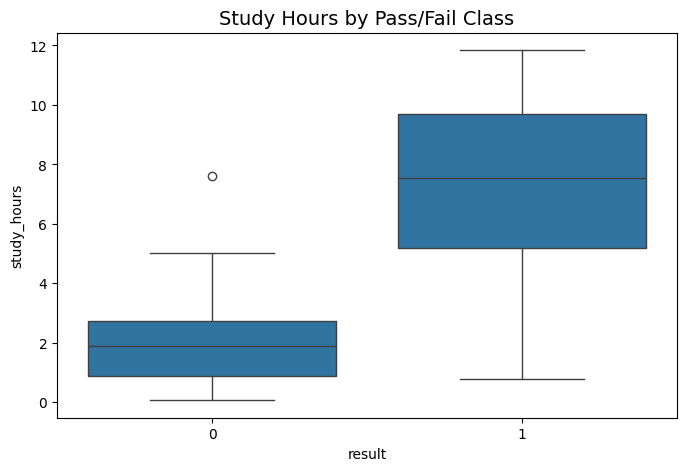

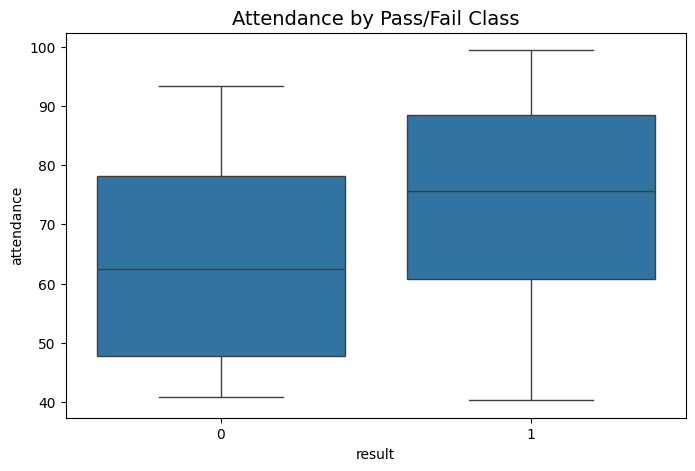


Correlation Matrix:
             study_hours  attendance    result
study_hours     1.000000    0.066531  0.709660
attendance      0.066531    1.000000  0.285639
result          0.709660    0.285639  1.000000


In [4]:
print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="study_hours", y="attendance", hue=TARGET_COL, palette={0: 'red', 1: 'green'}, alpha=0.8)
plt.title('Study Hours vs Attendance', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=TARGET_COL, y="study_hours")
plt.title('Study Hours by Pass/Fail Class', fontsize=14)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x=TARGET_COL, y="attendance")
plt.title('Attendance by Pass/Fail Class', fontsize=14)
plt.show()

corr = df[["study_hours", "attendance", TARGET_COL]].corr()
print("\nCorrelation Matrix:")
print(corr)

## 5. Feature Engineering & Scaling

Prepare features and scale them using StandardScaler.

In [5]:
print("="*60)
print("FEATURE ENGINEERING & SCALING")
print("="*60)

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFirst 5 rows of X:")
print(X[:5])
print("\nFirst 5 rows of scaled X:")
print(X_scaled[:5])

FEATURE ENGINEERING & SCALING
X shape: (180, 2)
y shape: (180,)

First 5 rows of X:
[[ 4.49 60.46]
 [11.41 46.81]
 [ 8.78 95.48]
 [ 7.18 92.64]
 [ 1.87 55.48]]

First 5 rows of scaled X:
[[-0.33398643 -0.57875915]
 [ 1.63251558 -1.36671669]
 [ 0.88513115  1.44279933]
 [ 0.4304486   1.27885798]
 [-1.07852911 -0.86623377]]


## 6. Theory

Logistic Regression is used for binary classification. It predicts the probability of a class using the sigmoid function.

**Sigmoid:** $σ(z) = 1 / (1 + e^{-z})$

If probability is greater than or equal to 0.5, the class is predicted as pass (1), otherwise fail (0).

## 7. Mathematical Representation


1. Linear combination: $z = eta_0 + eta_1x_1 + eta_2x_2$
2. Sigmoid function: $p = 1 / (1 + e^{-z})$
3. Class prediction: pass if $p e 0.5$, otherwise fail
4. Loss function: binary cross-entropy

## 8. Workflow Diagram

WORKFLOW DIAGRAM


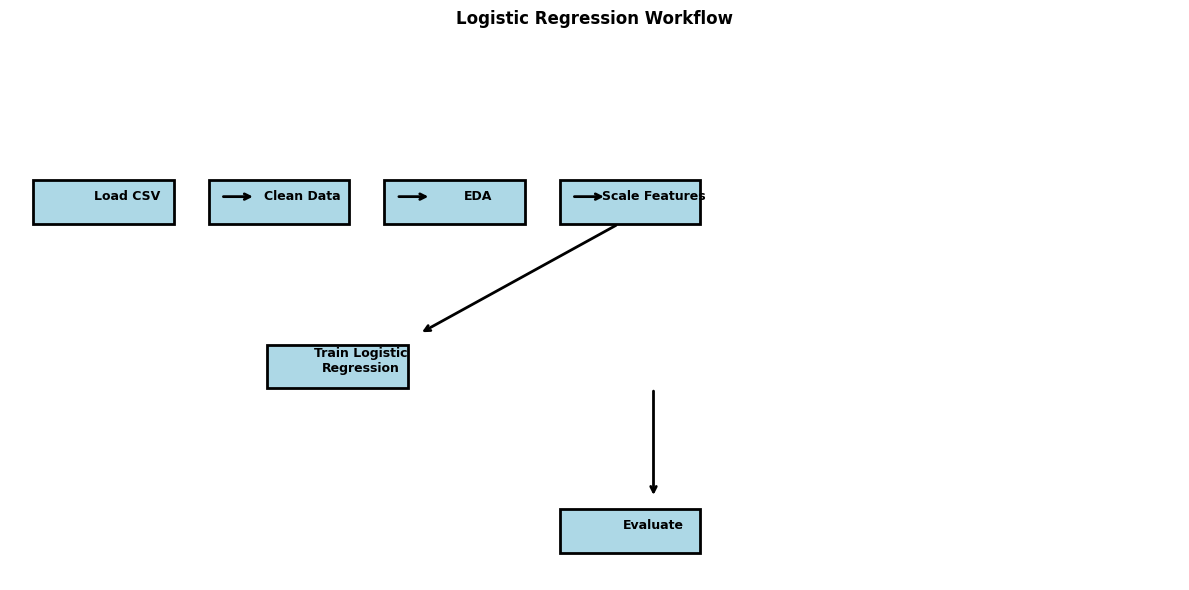

In [6]:
print("="*60)
print("WORKFLOW DIAGRAM")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

from matplotlib.patches import Rectangle
workflow_steps = [
    (0.1, 0.7, "Load CSV"),
    (0.25, 0.7, "Clean Data"),
    (0.4, 0.7, "EDA"),
    (0.55, 0.7, "Scale Features"),
    (0.3, 0.4, "Train Logistic\nRegression"),
    (0.55, 0.1, "Evaluate"),
]

for step_x, step_y, label in workflow_steps:
    rect = Rectangle((step_x - 0.08, step_y - 0.05), 0.12, 0.08, facecolor='lightblue', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(step_x, step_y, label, ha='center', va='center', fontsize=9, fontweight='bold')

arrows = [((0.18, 0.7), (0.21, 0.7)), ((0.33, 0.7), (0.36, 0.7)), ((0.48, 0.7), (0.51, 0.7)), ((0.52, 0.65), (0.35, 0.45)), ((0.55, 0.35), (0.55, 0.15))]
for start, end in arrows:
    ax.annotate('', xy=end, xytext=start, arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_title('Logistic Regression Workflow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Pseudocode

```
1. Load the student pass/fail dataset
2. Clean data and remove invalid rows
3. Split the dataset into features and target
4. Scale the features using StandardScaler
5. Split data into training and testing sets
6. Train a Logistic Regression model
7. Predict pass/fail labels on test data
8. Evaluate using accuracy, precision, recall, F1-score, and confusion matrix
9. Save the model and scaler
```

## 10. Train-Test Split and Model Training

In [7]:
print("="*60)
print("TRAIN-TEST SPLIT AND MODEL TRAINING")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Coefficients: {model.coef_[0]}")
print(f"Intercept: {model.intercept_[0]:.4f}")

TRAIN-TEST SPLIT AND MODEL TRAINING
Train size: 144 samples
Test size: 36 samples
Model trained successfully!
Coefficients: [2.86930998 1.07716704]
Intercept: 2.1128


## 11. Model Evaluation

In [8]:
print("="*60)
print("MODEL EVALUATION")
print("="*60)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

print("Sample predictions:")
for i in range(min(8, len(y_test))):
    actual = 'Pass' if y_test[i] == 1 else 'Fail'
    predicted = 'Pass' if y_pred[i] == 1 else 'Fail'
    prob = y_prob[i]
    print(f"Actual: {actual:<5} | Predicted: {predicted:<5} | Pass Probability: {prob:.3f}")

MODEL EVALUATION
Accuracy:  0.9722
Precision: 0.9600
Recall:    1.0000
F1 Score:  0.9796

Confusion Matrix:
[[11  1]
 [ 0 24]]

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.92      0.96        12
        Pass       0.96      1.00      0.98        24

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36

Sample predictions:
Actual: Pass  | Predicted: Pass  | Pass Probability: 1.000
Actual: Fail  | Predicted: Fail  | Pass Probability: 0.281
Actual: Fail  | Predicted: Fail  | Pass Probability: 0.406
Actual: Pass  | Predicted: Pass  | Pass Probability: 0.999
Actual: Pass  | Predicted: Pass  | Pass Probability: 0.901
Actual: Pass  | Predicted: Pass  | Pass Probability: 0.999
Actual: Fail  | Predicted: Fail  | Pass Probability: 0.083
Actual: Pass  | Predicted: Pass  | Pass Probability: 0.986


## 12. Obtained Output

OBTAINED OUTPUT - VISUALIZATIONS


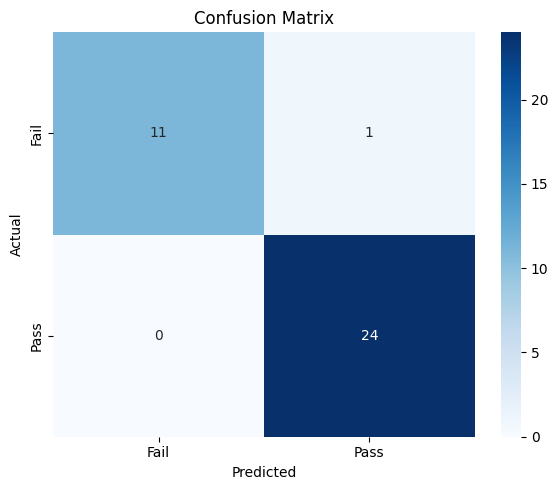

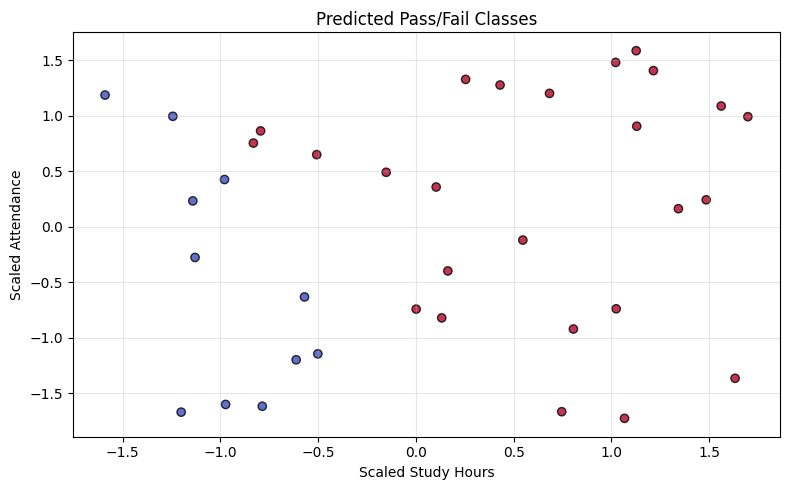

 Model and scaler saved successfully
Final Summary:
  Accuracy: 0.9722
  Precision: 0.9600
  Recall: 1.0000
  F1 Score: 0.9796


In [10]:
print("="*60)
print("OBTAINED OUTPUT - VISUALIZATIONS")
print("="*60)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', alpha=0.8, edgecolors='black')
plt.xlabel('Scaled Study Hours')
plt.ylabel('Scaled Attendance')
plt.title('Predicted Pass/Fail Classes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

joblib.dump(model, '5_logistic_pass_fail_model.joblib')
joblib.dump(scaler, '5_logistic_pass_fail_scaler.joblib')

print(" Model and scaler saved successfully")
print("Final Summary:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")